In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [26]:
df = pd.read_csv('D:/CustomerSegmentationAnalysis/data/ecommerce_customers.csv')
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [27]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB


,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,275.500000,33.597143,845.381714,12.600000,4.019143,26.588571
std,101.180532,4.870882,362.058695,4.155984,0.580539,13.440813
min,101.000000,26.000000,410.800000,7.000000,3.000000,9.000000
25%,188.250000,30.000000,502.000000,9.000000,3.500000,15.000000
50%,275.500000,32.500000,775.200000,12.000000,4.100000,23.000000
75%,362.750000,37.000000,1160.600000,15.000000,4.500000,38.000000
max,450.000000,43.000000,1520.100000,21.000000,4.900000,63.000000


In [28]:
rfm = df[['Days Since Last Purchase','Items Purchased','Total Spend']]
rfm.columns = ['Recency','Frequency','Monetary']

rfm.head()

,Recency,Frequency,Monetary
0,25,14,1120.20
1,18,11,780.50
2,42,9,510.75
3,12,19,1480.30
4,55,13,720.40


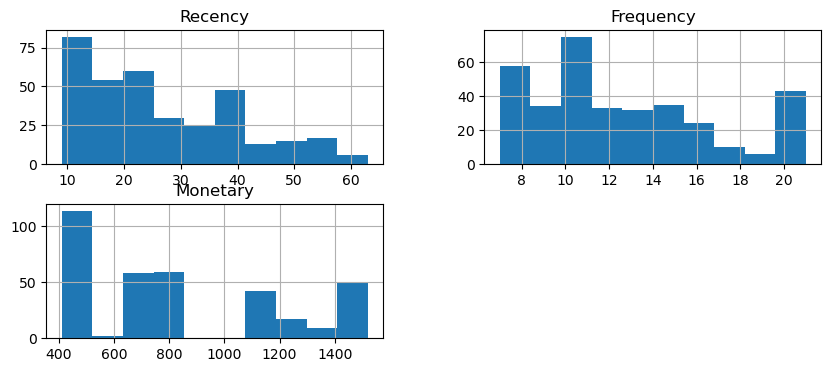

In [29]:
rfm.hist(figsize=(10,4))
plt.show()

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

C:\Users\riyar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\riyar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\riyar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\riyar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

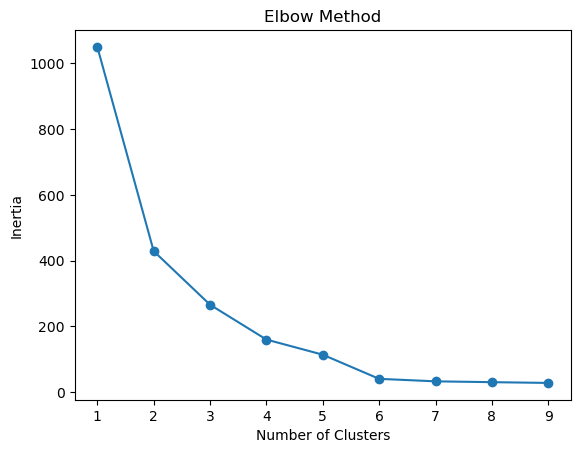

In [31]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,10):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [32]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(rfm_scaled)

C:\Users\riyar\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [33]:
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,Cluster
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied,1
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral,1
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied,3
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied,2
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied,3


In [34]:
cluster_summary = df.groupby('Cluster')[['Total Spend','Items Purchased','Days Since Last Purchase']].mean()

cluster_summary

,Total Spend,Items Purchased,Days Since Last Purchase
Cluster,,,
0,500.180000,8.370000,28.240000
1,985.263559,13.474576,19.932203
2,1459.772414,20.000000,11.172414
3,607.266216,11.121622,47.054054


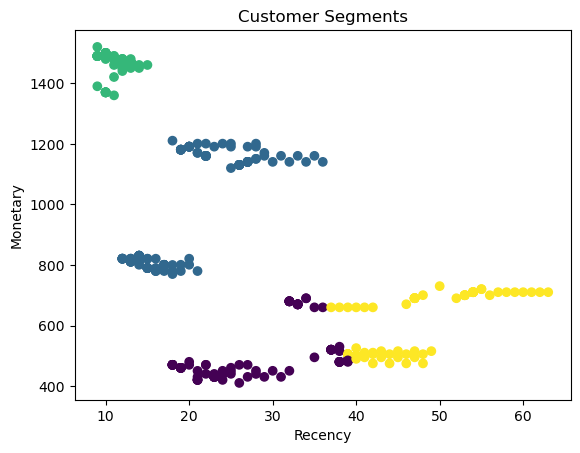

In [37]:
plt.scatter(df['Days Since Last Purchase'],
            df['Total Spend'],
            c=df['Cluster'])

plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.title('Customer Segments')
plt.savefig('D:/CustomerSegmentationAnalysis/images/cluster_plot.png')
plt.show()

In [38]:
segment_map = {
    0: 'VIP',
    1: 'At Risk',
    2: 'Budget',
    3: 'Regular'
}

df['Segment'] = df['Cluster'].map(segment_map)

In [39]:
df['Segment'].value_counts()

Segment
At Risk    118
VIP        100
Regular     74
Budget      58
Name: count, dtype: int64

In [40]:
df.to_csv('D:/CustomerSegmentationAnalysis/data/ecommerce_customers_clustered.csv', index=False)

In [41]:
print(cluster_summary)

         Total Spend  Items Purchased  Days Since Last Purchase
Cluster                                                        
0         500.180000         8.370000                 28.240000
1         985.263559        13.474576                 19.932203
2        1459.772414        20.000000                 11.172414
3         607.266216        11.121622                 47.054054
